# Stage 12: the evaluation

**Everything else in the thesis reports to this stage.** Four variants —
the score alone (V3, the baseline) and the score followed by a feature
judge (V1), an image judge (V2) or a quantum judge (V4) — run end to end
on seven held-out real dwellings, under both sets of score weights, and
are compared on their agreement with the derived labels using paired
statistics. The protocol is set out in this folder's README; this notebook
renders the tables it produced.

**Candidate coverage comes first.** If the derived arrangement is not
among the candidates, an accuracy figure measures that absence rather than
the quality of any variant. After aligning stages 04 and 05 with the
labelling procedure it is present for **7 of 7** plans, so everything
below is unconditional.

One basis of comparison has been removed. A lateral drift index previously
provided a second measurement that did not depend on the derived labels.
With it gone, the table below is the whole comparison, and every figure in
it is conditional on the labelling procedure of stage 02. The threshold
sensitivity at the end of this notebook is the nearest available check on
that dependence.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = Path("..") / "data"
acc = pd.read_csv(DATA / "evaluation_accuracy.csv")
tests = pd.read_csv(DATA / "evaluation_tests.csv")

print(f"plans: {acc.plan.nunique()}, coverage: "
      f"{acc.groupby('plan').reachable.first().mean():.0%}")
print(f"candidates per plan: "
      f"{acc.groupby('plan').n_candidates.first().min()}"
      f"-{acc.groupby('plan').n_candidates.first().max()}")
print()
print("THE ACCURACY TABLE (mean over plans)")
print(acc.groupby(["mode", "variant"])[
    ["rank_gt", "top1", "top5", "chamfer_m", "iou"]]
    .mean().round(3).to_string())
print()
print("median rank of the derived arrangement:")
print(acc.groupby(["mode", "variant"]).rank_gt.median().to_string())

plans: 7, coverage: 100%
candidates per plan: 512-4000

THE ACCURACY TABLE (mean over plans)
                  rank_gt   top1   top5  chamfer_m    iou
mode    variant                                          
algo    V1       2429.286  0.000  0.000      1.000  0.287
        V2       2429.286  0.000  0.000      0.958  0.312
        V3       2429.286  0.000  0.000      1.000  0.287
        V4       2429.286  0.000  0.000      1.000  0.287
learned V1         21.857  0.000  0.429      0.248  0.704
        V2         21.714  0.143  0.429      0.264  0.718
        V3         21.714  0.143  0.429      0.271  0.722
        V4         22.000  0.143  0.429      0.282  0.683

median rank of the derived arrangement:
mode     variant
algo     V1         2395.0
         V2         2395.0
         V3         2395.0
         V4         2395.0
learned  V1           10.0
         V2            9.0
         V3            9.0
         V4           11.0


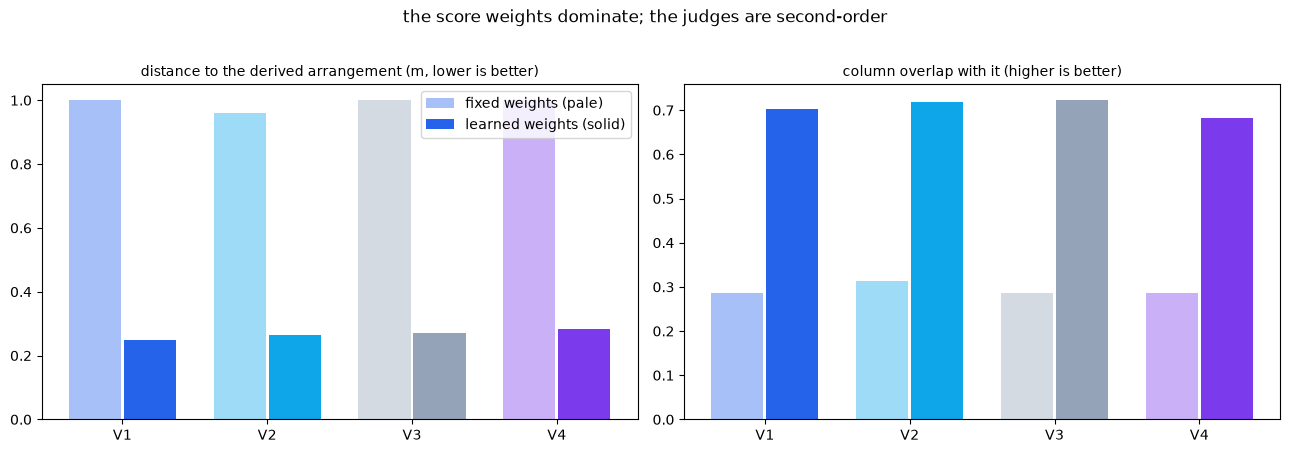

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
order = ["V1", "V2", "V3", "V4"]
colours = {"V1": "#2563eb", "V2": "#0ea5e9", "V3": "#94a3b8", "V4": "#7c3aed"}
for ax, metric, title in ((axes[0], "chamfer_m",
                           "distance to the derived arrangement (m, lower is better)"),
                          (axes[1], "iou",
                           "column overlap with it (higher is better)")):
    for i, mode in enumerate(("algo", "learned")):
        sub = acc[acc["mode"] == mode].groupby("variant")[metric].mean()
        x = np.arange(len(order)) + (i - 0.5) * 0.38
        ax.bar(x, [sub[v] for v in order], 0.36,
               color=[colours[v] for v in order],
               alpha=1.0 if mode == "learned" else 0.4)
    ax.set_xticks(np.arange(len(order)), order)
    ax.set_title(title, fontsize=10)
axes[0].legend(["fixed weights (pale)", "learned weights (solid)"])
fig.suptitle("the score weights dominate; the judges are second-order",
             y=1.02)
fig.tight_layout()
fig.savefig(Path("..") / "figures" / "12_accuracy.png", dpi=150,
            bbox_inches="tight")
plt.show()

## Reading the table

**The score weights are the story.** Under fixed weights the derived
arrangement sits at median rank about 2,400 of roughly 4,000 for every
variant: the equal-weight score prefers sparse, regular grids, while real
wall-derived arrangements are dense and irregular, which is what stage
08's negative density and irregularity coefficients predicted. Under the
learned weights the score *alone* places it at median rank 9, recovers it
exactly on one of seven plans, and averages 0.27 m distance.

**The judges are second-order, and none helps consistently.** Each judge
moves the ranking on at most two of the seven plans, in mixed directions:
V1 trades the first-place recovery away for the best distance of the four
(0.248 m against 0.271 m), V2 trims the distance slightly at the cost of
a little overlap, and V4, trained on the same 80% partition as the other
two judges, recovers the arrangement first on one plan and gives the
weakest agreement of the four.

**Nothing separates from the baseline at seven plans.** Every paired test
below returns p = 1.000: the differences are few, small and mixed in
direction; both facts are reported.

In [3]:
print("paired tests, all pairs where the variants differ:")
print(tests[tests.wilcoxon_p < 1.0].round(3).to_string(index=False))

paired tests, all pairs where the variants differ:
Empty DataFrame
Columns: [mode, metric, pair, mean_a, mean_b, wilcoxon_p, sign_p, n_plans]
Index: []


In [4]:
lam = pd.read_csv(DATA / "evaluation_lambda.csv")
print("lambda ablation (V1), both score modes:")
print(lam.groupby(["mode", "lambda"])[["rank_gt", "top1", "top5"]]
      .mean().round(3).to_string())
print()
sens = pd.read_csv(DATA / "evaluation_weights_sensitivity.csv")
print("score-weight sensitivity (V3, fixed weights):")
print(sens.groupby("perturbation")[
    ["kendall_tau", "top1_same", "top5_overlap", "rank_gt"]]
    .mean().round(3).to_string())

lambda ablation (V1), both score modes:
                 rank_gt   top1   top5
mode    lambda                        
algo    0.0     2429.286  0.000  0.000
        0.1     2429.286  0.000  0.000
        0.3     2429.286  0.000  0.000
        0.5     2429.286  0.000  0.000
        1.0     2429.286  0.000  0.000
learned 0.0       21.714  0.143  0.429
        0.1       21.571  0.143  0.429
        0.3       21.857  0.000  0.429
        0.5       21.857  0.000  0.429
        1.0       21.857  0.000  0.429

score-weight sensitivity (V3, fixed weights):
                        kendall_tau  top1_same  top5_overlap   rank_gt
perturbation                                                          
nominal                       1.000      1.000         1.000  2429.286
t_density +50%                0.881      0.857         0.857  2873.286
t_density -50%                0.853      0.857         0.943  1555.714
t_density dropped             0.690      0.571         0.829   642.857
t_irregularity +50%

In [5]:
thr = pd.read_csv(DATA / "evaluation_threshold.csv")
ok = thr[thr.derivable == True]
print("label threshold sensitivity, both score modes:")
print(ok.groupby(["mode", "threshold_mm", "variant"])[
    ["rank_gt", "top1", "top5", "chamfer_m", "gt_n_columns"]]
    .mean().round(3).to_string())
print()
ov = pd.read_csv(DATA / "evaluation_overlap.csv")
print(f"score against judge, rank correlation: mean "
      f"{ov.spearman_penalty_vs_judge.mean():.3f}, range "
      f"[{ov.spearman_penalty_vs_judge.min():.3f}, "
      f"{ov.spearman_penalty_vs_judge.max():.3f}]. A value near 1 would "
      f"mean the judge adds nothing.")

label threshold sensitivity, both score modes:
                               rank_gt   top1   top5  chamfer_m  gt_n_columns
mode    threshold_mm variant                                                 
algo    140          V1       2853.714  0.000  0.000      1.060        74.000
                     V3       2853.714  0.000  0.000      1.060        74.000
        160          V1       2429.286  0.000  0.000      1.000        57.286
                     V3       2429.286  0.000  0.000      1.000        57.286
        180          V1       2198.000  0.000  0.000      1.123        48.286
                     V3       2198.000  0.000  0.000      1.123        48.286
        200          V1       2162.286  0.000  0.000      1.159        43.714
                     V3       2162.286  0.000  0.000      1.159        43.714
learned 140          V1         23.714  0.143  0.429      0.208        74.000
                     V3         24.143  0.143  0.429      0.232        74.000
        160      

## What the sensitivity analyses establish

Varying any single score weight by ±50% keeps the rank correlation with
the nominal ordering at 0.85 to 0.92 and leaves four-fifths of the top
five unchanged, which is the empirical defence of the equal-weight vector.
Removing a measure entirely costs more (0.69 to 0.78), so every measure
carries real ordering information. One perturbation is diagnostic:
removing the density measure *improves* the derived arrangement's mean
rank from 2,429 to 643, which independently confirms the negative density
coefficient the learned weights found.

The judge's influence, lambda, matters little and in both directions: from
0 to 1 it moves the mean rank from 21.7 to 21.9, costs one first-place
recovery and leaves the top-five rate unchanged. The default of 0.3 is
defensible precisely because so little depends on it.

The label threshold is the most consequential assumption in the thesis.
Re-deriving the labels from each plan's own wall thicknesses gives a
median-regime rank of about 24 at 140 mm and 22 at 160 mm, then 90 at
180 mm and 195 at 200 mm, with distance rising from 0.23 m to 0.61 m. The
result is stable across 140 to 160 mm and degrades beyond, partly because
the corpus the weights were learned from was itself derived at 160 mm.
Every figure in this thesis is conditional on that constant, and this
table is the price of it.

Finally, the score's ordering and the feature judge's are nearly
independent (rank correlation 0.16, range 0.08 to 0.28). The judge
carries genuinely different information; it simply does not carry much
that helps place the derived arrangement once the learned weights have
done their work.